
# กำลังรันการอนุมานทั้งมวล StormCast

ชุด StormCast inference workflow

ตัวอย่างนี้จะสาธิตวิธีการรัน inference workflow อย่างง่ายเพื่อสร้าง
ensemble forecast โดยใช้ StormCast สำหรับรายละเอียดเกี่ยวกับโมเดล Stormcast
ดู

- https://arxiv.org/abs/2408.10958


In [ ]:
# /// script
# dependencies = [
#   "earth2studio[data,stormcast] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การเตรียมองค์ประกอบ
workflow ทุกตัวภายใน Earth2Studio จำเป็นต้องได้รับคอมโพเนนต์ที่สร้างไว้ล่วงหน้า
แล้วส่งเข้าไปให้ใช้งาน ในตัวอย่างนี้ ลองมาดู ensemble workflow พื้นฐานที่สุดกัน:
:py:meth:`earth2studio.run.ensemble`.



.. literalinclude:: ../../earth2studio/run.py
   :language: python
   :start-after: # sphinx - ensemble start
   :end-before: # sphinx - ensemble end



ดังนั้น เราจึงต้องมีองค์ประกอบต่อไปนี้:

- Prognostic Model: ใช้ StormCast รุ่น :py:class:`earth2studio.models.px.StormCast` ในตัว
- perturbation_method: ใช้วิธี Zero :py:class:`earth2studio.perturbation.Zero` เราจะไม่
รบกวนข้อมูลเริ่มต้นเนื่องจาก StormCast มีการสร้างสมาชิก ensemble สุ่ม
- Datasource: ดึงข้อมูลจาก HRRR data API ผ่าน :py:class:`earth2studio.data.HRRR`.
- IO Backend: บันทึกผลลัพธ์ลงใน Zarr store ผ่าน :py:class:`earth2studio.io.ZarrBackend`.

StormCast ยังต้องการแหล่งข้อมูลการปรับสภาพด้วย เราใช้แหล่งข้อมูล forecast ที่นี่
ARCO :py:class:`earth2studio.data.ARCO` แต่เป็นแหล่งข้อมูล forecast เช่น GFS_FX
สามารถใช้กับการประทับเวลาที่เหมาะสมได้



In [1]:
import numpy as np
from loguru import logger
from tqdm import tqdm

logger.remove()
logger.add(lambda msg: tqdm.write(msg, end=""), colorize=True)

import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from earth2studio.data import ARCO, HRRR
from earth2studio.io import ZarrBackend
from earth2studio.models.px import StormCast
from earth2studio.perturbation import Zero

# สร้างและตั้งค่าแหล่งข้อมูลการปรับสภาพ
conditioning_data_source = ARCO()

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = StormCast.load_default_package()
model = StormCast.load_model(package, conditioning_data_source=conditioning_data_source)

# สร้างตัวอย่างวิธีการก่อกวน (ศูนย์)
z = Zero()

# สร้างแหล่งข้อมูล
data = HRRR()

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
io = ZarrBackend()

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature
2026-04-24 15:36:19.926 | DEBUG    | earth2studio.data.arco:_async_init:131 - Using Multi-Storage Client for ARCO data access


## การรัน Workflow
เมื่อคอมโพเนนต์ทั้งหมดเริ่มต้นแล้ว การรัน workflow จะเป็นโค้ด Python บรรทัดเดียว
เวิร์กโฟลว์จะส่งคืนอ็อบเจ็กต์ IO ที่ระบุกลับไปยังผู้ใช้ ซึ่งสามารถนำมาใช้ได้
จากนั้นจึงโพสต์กระบวนการ บางตัวมี API เพิ่มเติมซึ่งมีประโยชน์สำหรับ post-processing หรือ
บันทึกเป็นไฟล์ ตรวจสอบเอกสาร API สำหรับข้อมูลเพิ่มเติม

สำหรับการพยากรณ์ เราจะคาดการณ์เป็นเวลา 4 ชั่วโมง



In [2]:
import earth2studio.run as run

nsteps = 4
nensemble = 4
batch_size = 2

date = "2022-11-04T21:00:00"
io = run.ensemble(
    [date],
    nsteps,
    nensemble,
    model,
    data,
    io,
    z,
    batch_size=batch_size,
    output_coords={"variable": np.array(["t2m", "refc"])},
)

print(io.root.tree())

2026-04-24 15:36:45.618 | INFO     | earth2studio.run:ensemble:328 - Running ensemble inference!
2026-04-24 15:36:45.619 | INFO     | earth2studio.run:ensemble:336 - Inference device: cuda


Fetching HRRR data:   0%|          | 0/99 [00:00<?, ?it/s]

2026-04-24 15:36:47.787 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20221104/conus/hrrr.t21z.wrfsfcf00.grib2 26658825-637820
2026-04-24 15:36:47.790 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20221104/conus/hrrr.t21z.wrfnatf00.grib2 125408221-1046332
2026-04-24 15:36:47.792 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20221104/conus/hrrr.t21z.wrfnatf00.grib2 0-2231725
2026-04-24 15:36:47.794 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20221104/conus/hrrr.t21z.wrfnatf00.grib2 140679865-1017377
2026-04-24 15:36:47.796 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching HRRR grib file: noaa-hrrr-bdp-pds/hrrr.20221104/conus/hrrr.t21z.wrfnatf00.grib2 13759195-2231917
2026-04-24 15:36:47.798 | DEBUG    | earth2studio.data.hrrr:fetch_array:509 - Fetching

Fetching HRRR data: 100%|██████████| 99/99 [00:15<00:00,  6.38it/s]


2026-04-24 15:37:03.439 | SUCCESS  | earth2studio.run:ensemble:358 - Fetched data from HRRR
2026-04-24 15:37:03.447 | INFO     | earth2studio.run:ensemble:386 - Starting 4 Member Ensemble Inference with             2 number of batches.


...

2026-04-24 15:47:01.280 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: v10m at 2022-11-04T23:00:00
2026-04-24 15:47:01.284 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z850 at 2022-11-04T23:00:00
2026-04-24 15:47:01.287 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: v1000 at 2022-11-04T23:00:00
2026-04-24 15:47:01.291 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: q250 at 2022-11-04T23:00:00
2026-04-24 15:47:01.295 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: u10m at 2022-11-04T23:00:00
2026-04-24 15:47:01.298 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z500 at 2022-11-04T23:00:00
2026-04-24 15:47:01.302 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: v850 at 2022

Fetching ARCO data:   0%|          | 0/26 [00:00<?, ?it/s]

                                                                
                                                                        
Fetching ARCO data:   0%|          | 0/26 [00:00<?, ?it/s]

                                                                
                                                                        
Fetching ARCO data:   0%|          | 0/26 [00:00<?, ?it/s]

                                                                
                                                                        
Fetching ARCO data:   0%|          | 0/26 [00:00<?, ?it/s]

                                                                
                                                                        
Fetching ARCO data:   0%|          | 0/26 [00:00<?, ?it/s]

                                                                
                                                                        
Fetching A

2026-04-24 15:47:53.876 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: u10m at 2022-11-05T00:00:00
2026-04-24 15:47:53.880 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t2m at 2022-11-05T00:00:00
2026-04-24 15:47:53.883 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: v500 at 2022-11-05T00:00:00
2026-04-24 15:47:53.887 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: z250 at 2022-11-05T00:00:00
2026-04-24 15:47:53.891 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: tcwv at 2022-11-05T00:00:00
2026-04-24 15:47:53.895 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: t1000 at 2022-11-05T00:00:00
2026-04-24 15:47:53.898 | DEBUG    | earth2studio.data.arco:fetch_array:301 - Fetching ARCO zarr array for variable: sp at 2022-11

Fetching ARCO data: 100%|██████████| 26/26 [00:00<00:00, 26.21it/s]

Total Ensemble Batches: 100%|██████████| 2/2 [11:43<00:00, 351.51s/it]

2026-04-24 15:48:46.477 | SUCCESS  | earth2studio.run:ensemble:439 - 
Inference complete
/
├── ensemble (4,) int64
├── hrrr_x (640,) float64
├── hrrr_y (512,) float64
├── lead_time (5,) timedelta64[h]
├── refc (4, 1, 5, 512, 640) float32
├── t2m (4, 1, 5, 512, 640) float32
└── time (1,) datetime64[ns]



## การทำ Post-Processing
ขั้นตอนสุดท้ายคือการนำผลลัพธ์มาทำ post-process ต่อ Cartopy เป็นไลบรารีที่ยอดเยี่ยมสำหรับการพล็อต
ฟิลด์ข้อมูลบน projection ของทรงกลม เริ่มจากการพล็อตค่าการสะท้อนเรดาร์

สังเกตว่าฟังก์ชัน Zarr IO มี API เพิ่มเติมสำหรับใช้เข้าถึงและจัดการข้อมูลที่เก็บไว้



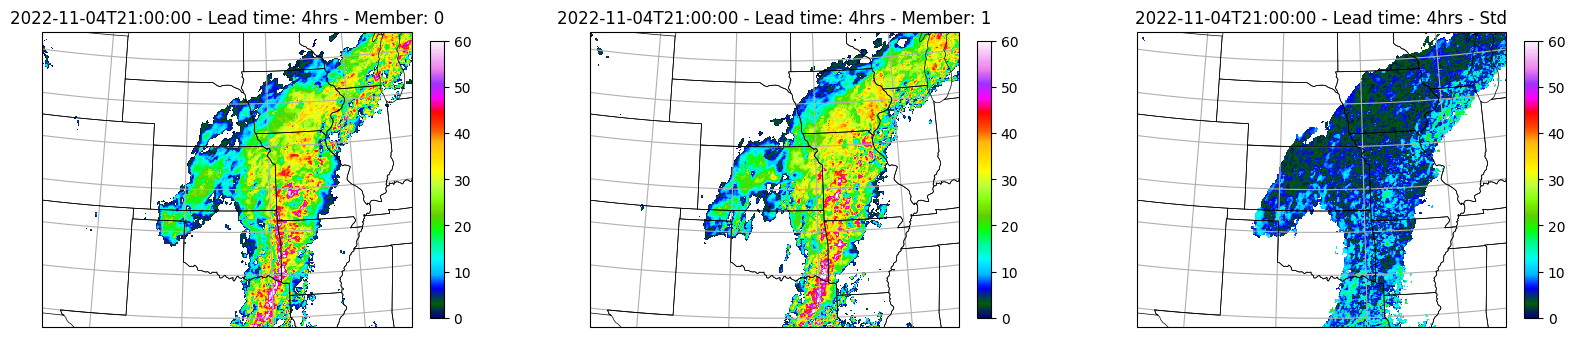

In [3]:
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

forecast = f"{date}"
step = nsteps  # 4 ชั่วโมง เนื่องจาก lead_time = 1 ชม

# สร้าง Lambert Conformal projection ที่ถูกต้อง
projection = ccrs.LambertConformal(
    central_longitude=262.5,
    central_latitude=38.5,
    standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)


# รับอาร์เรย์ lat lon จากโมเดล
def plot_(axi, data, title, cmap, vmin=None, vmax=None):
    """Convenience function for plotting pcolormesh."""
    # พล็อตฟิลด์โดยใช้ pcolormesh
    im = axi.pcolormesh(
        model.lon,
        model.lat,
        data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(im, ax=axi, shrink=0.6, pad=0.04)
    # ตั้งชื่อเรื่อง
    axi.set_title(title)

    # เพิ่มแนวชายฝั่งและเส้นกริด
    axi.coastlines()
    axi.gridlines()

    # กำหนดเส้นสถานะ
    axi.add_feature(
        cartopy.feature.STATES.with_scale("50m"),
        linewidth=0.5,
        edgecolor="black",
        zorder=2,
    )


# พล็อตอ้างอิง
variable = "refc"
cmap = "gist_ncar"
x = io[variable]

plt.close("all")
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1, ncols=3, subplot_kw={"projection": projection}, figsize=(20, 6)
)
plot_(
    ax1,
    np.where(x[0, 0, step] > 0, x[0, 0, step], np.nan),
    f"{forecast} - Lead time: {step}hrs - Member: {0}",
    cmap,
    vmin=0,
    vmax=60,
)
plot_(
    ax2,
    np.where(x[1, 0, step] > 0, x[1, 0, step], np.nan),
    f"{forecast} - Lead time: {step}hrs - Member: {1}",
    cmap,
    vmin=0,
    vmax=60,
)
plot_(
    ax3,
    np.where(x[:, 0, step].mean(axis=0) > 0, x[:, 0, step].std(axis=0), np.nan),
    f"{forecast} - Lead time: {step}hrs - Std",
    cmap,
    vmin=0,
    vmax=60,
)
plt.savefig(f"outputs/10_{date}_{variable}_{step}_ensemble.jpg")

ลองพล็อตสนามอุณหภูมิพื้นผิวด้วย



แปลงอุณหภูมิ 2 เมตร



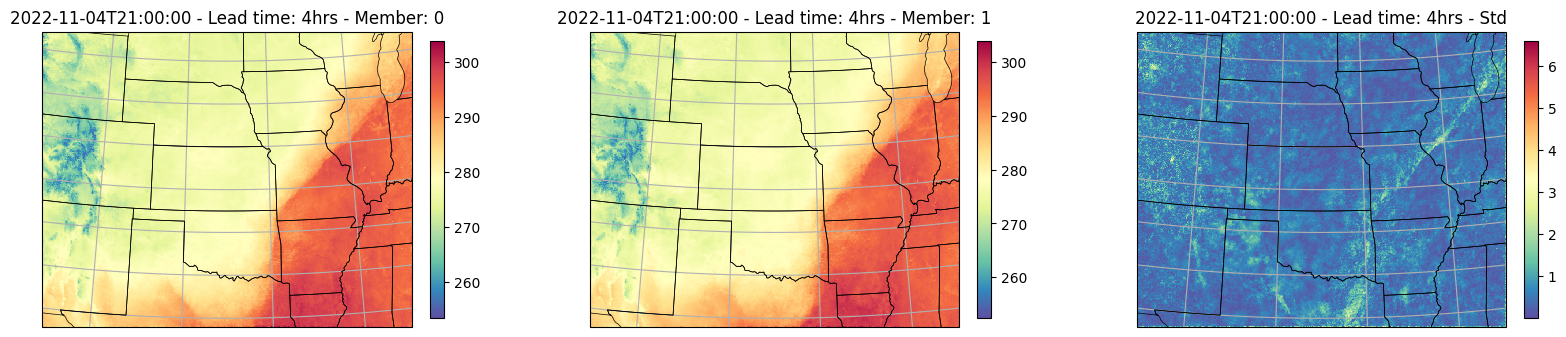

In [4]:
variable = "t2m"
cmap = "Spectral_r"
x = io[variable]

plt.close("all")
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1, ncols=3, subplot_kw={"projection": projection}, figsize=(20, 6)
)
plot_(
    ax1,
    x[0, 0, step],
    f"{forecast} - Lead time: {step}hrs - Member: {0}",
    cmap,
)
plot_(
    ax2,
    io[variable][1, 0, step],
    f"{forecast} - Lead time: {step}hrs - Member: {1}",
    cmap,
)
plot_(
    ax3,
    x[:, 0, step].std(axis=0),
    f"{forecast} - Lead time: {step}hrs - Std",
    cmap,
)
plt.savefig(f"outputs/10_{date}_{variable}_{step}_ensemble.jpg")